# Cadrage du Projet  


## formulation du probléme:

À partir des données du patient, prédire la présence ou l'absence de maladie cardiaque.

Type : Classification supervisée
Cible : target (0 ou 1)

Description
***
* **Features:**
***
- age [years]
***
- sex:  Patient’s biological sex
****
- chest_pain_type:  Type of chest pain experienced by the patient:
Code	Description:   
0	Typical angina (usually cardiac)  
1	Atypical angina  
2	Non-anginal pain  
3	Asymptomatic  

****
- resting_bp_s:

Resting systolic blood pressure

Unit: mm Hg

Normal ≈ 120 mm Hg
***
- cholesterol

Serum cholesterol level

Unit: mg/dl
***
- fasting_blood_sugar

Whether fasting blood sugar > 120 mg/dl
Values:

1 = True (high fasting blood sugar)

0 = False
***
- resting_ecg

Resting electrocardiogram results:

Code	Meaning:  
0	Normal  
1	ST-T wave abnormality  
2	Left ventricular hypertrophy
***
- max_heart_rate

Maximum heart rate achieved during exercise

Unit: beats per minute (bpm)
***
- exercise_angina

Angina (chest pain) induced by exercise?

1 = Yes

0 = No
***
- oldpeak

ST depression induced by exercise

Unit: mm

Measures the difference from rest to peak exercise.
***
- st_slope

Slope of the ST segment during peak exercise:
***
- target

0 = No heart disease

1 = Presence of heart disease
***

****
**Context**

Heart Disease Dataset (Most comprehensive) Content Heart disease is also known as Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year which is about 32 of all deaths globally. CVDs are a group of disorders of the heart and blood vessels and include coronary heart disease, cerebrovascular disease, rheumatic heart disease, and other conditions. Four out of 5CVD deaths are due to heart attacks and strokes, and one-third of these deaths occur prematurely in people under 70 years of age. We have curated this dataset by combining different datasets already available independently but not combined before. We have combined them over 11 common features which makes it the largest heart disease dataset available for research purposes.

***The five datasets used for its curation are:***

***Database***  :         ***Number of instances***

Cleveland	:      303

Hungarian:     	294  

Switzerland:  	123

Long Beach VA	:   200

Stalog (Heart) Data Set	:  270
***
Total	:  1190

# Exploratory data analysis

## load data and import the packages

In [1]:
# install necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('/content/heart-disease-dataset.csv')

In [3]:
data

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,target
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,1.0,0.0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,1.0
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,1.0,0.0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0,1.0
4,54.0,1.0,3.0,150.0,195.0,0.0,0.0,122.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1185,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,1.0
1186,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,1.0
1187,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0
1188,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0


In [4]:
data.shape

(1190, 12)

In [6]:
# verify missing values
data.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp_s,0
cholesterol,0
fasting_blood_sugar,0
resting_ecg,0
max_heart_rate,0
exercise_angina,0
oldpeak,0


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   float64
 1   sex                  1190 non-null   float64
 2   chest_pain_type      1190 non-null   float64
 3   resting_bp_s         1190 non-null   float64
 4   cholesterol          1190 non-null   float64
 5   fasting_blood_sugar  1190 non-null   float64
 6   resting_ecg          1190 non-null   float64
 7   max_heart_rate       1190 non-null   float64
 8   exercise_angina      1190 non-null   float64
 9   oldpeak              1190 non-null   float64
 10  st_slope             1190 non-null   float64
 11  target               1190 non-null   float64
dtypes: float64(12)
memory usage: 111.7 KB


notre dataframe ne contient pas de valeurs manquantes.

In [7]:
# verify duplicated data
data.duplicated().sum()

np.int64(272)

vérifier pourquoi nous avons autant de doublons, vérifions cela ligne pas ligne et vérifions si ce ne sont pas des variables temporelles qui sont a l'origine de cela.

In [8]:
data.duplicated().value_counts()

,count
False,918
True,272


In [9]:
# verify duplicated data row by row
data[data.duplicated()]

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,target
163,49.0,0.0,2.0,110.0,208.0,0.0,0.0,160.0,0.0,0.0,1.0,0.0
604,58.0,1.0,3.0,150.0,219.0,0.0,1.0,118.0,1.0,0.0,2.0,1.0
887,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0
888,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,1.0
889,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1156,42.0,1.0,3.0,130.0,180.0,0.0,0.0,150.0,0.0,0.0,1.0,0.0
1157,61.0,1.0,4.0,140.0,207.0,0.0,2.0,138.0,1.0,1.9,1.0,1.0
1158,66.0,1.0,4.0,160.0,228.0,0.0,2.0,138.0,0.0,2.3,1.0,0.0
1159,46.0,1.0,4.0,140.0,311.0,0.0,0.0,120.0,1.0,1.8,2.0,1.0


Comme mon dataset provient de plusieurs sources donc je pense qu'il ne faut pas supprimer les doublons. Mais le mieux serais de rentrer au niveau de notre dataset original et ajouter le nom de chaque dataset dans une colonne et parv la suite crée une colonne Id qui va servir pour identifier chaque individu de notre base de donnée.

In [15]:
data.describe()

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,target
count,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000,1190.000000
mean,53.720168,0.763866,3.232773,132.153782,210.363866,0.213445,0.698319,139.732773,0.387395,0.922773,1.624370,0.528571
std,9.358203,0.424884,0.935480,18.368823,101.420489,0.409912,0.870359,25.517636,0.487360,1.086337,0.610459,0.499393
min,28.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.000000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,188.000000,0.000000,0.000000,121.000000,0.000000,0.000000,1.000000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,229.000000,0.000000,0.000000,140.500000,0.000000,0.600000,2.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,269.750000,0.000000,2.000000,160.000000,1.000000,1.600000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,1.000000


## Univariate analysis

In [11]:
# determine the number of unique value
data.nunique()

,0
age,50
sex,2
chest_pain_type,4
resting_bp_s,67
cholesterol,222
fasting_blood_sugar,2
resting_ecg,3
max_heart_rate,119
exercise_angina,2
oldpeak,53


Dans notre dataset on constate que nous avons les données catégorielles encodées, telles que le sex, chest_pain_type, fasting_blood_sugar, resting_ecg, exercise_angina, st_slope, target.

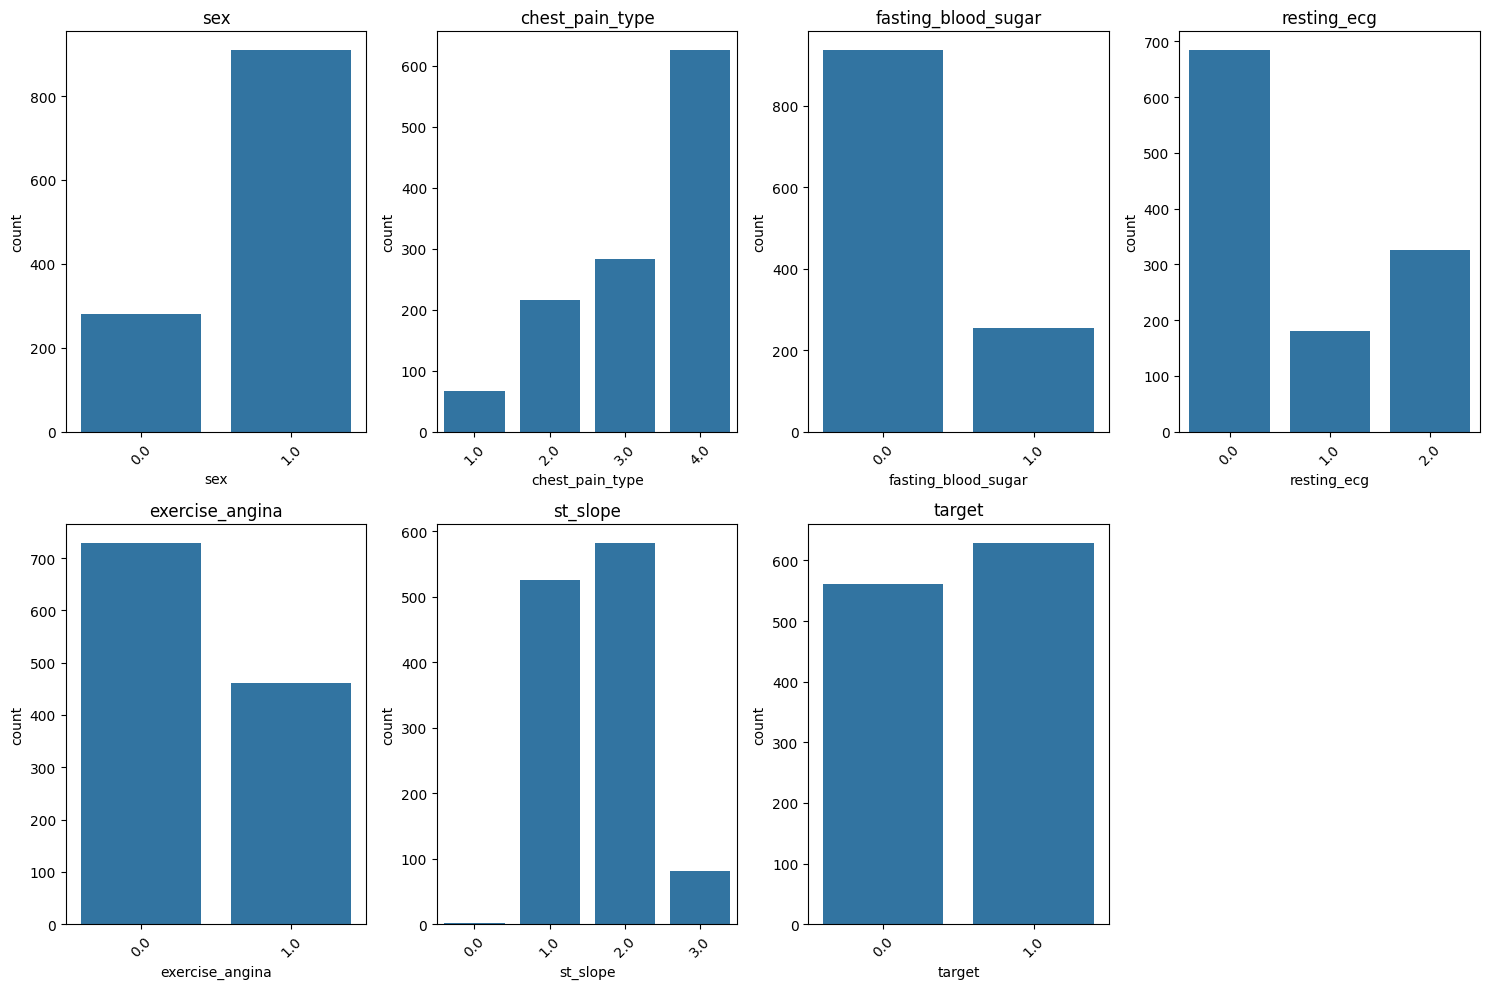

In [26]:
cat_var = ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'resting_ecg', 'exercise_angina', 'st_slope', 'target']

plt.figure(figsize=(15, 10))
for i, var_name in enumerate(cat_var):
    plt.subplot(2, 4, i+1)
    sns.countplot(x=data[var_name])
    plt.title(var_name)
    plt.xticks(rotation=45)  # pour faire pivoter les labels si besoin
plt.tight_layout()
plt.show()

histogramme des variables quantitatives
boxplot des variables quantitatives


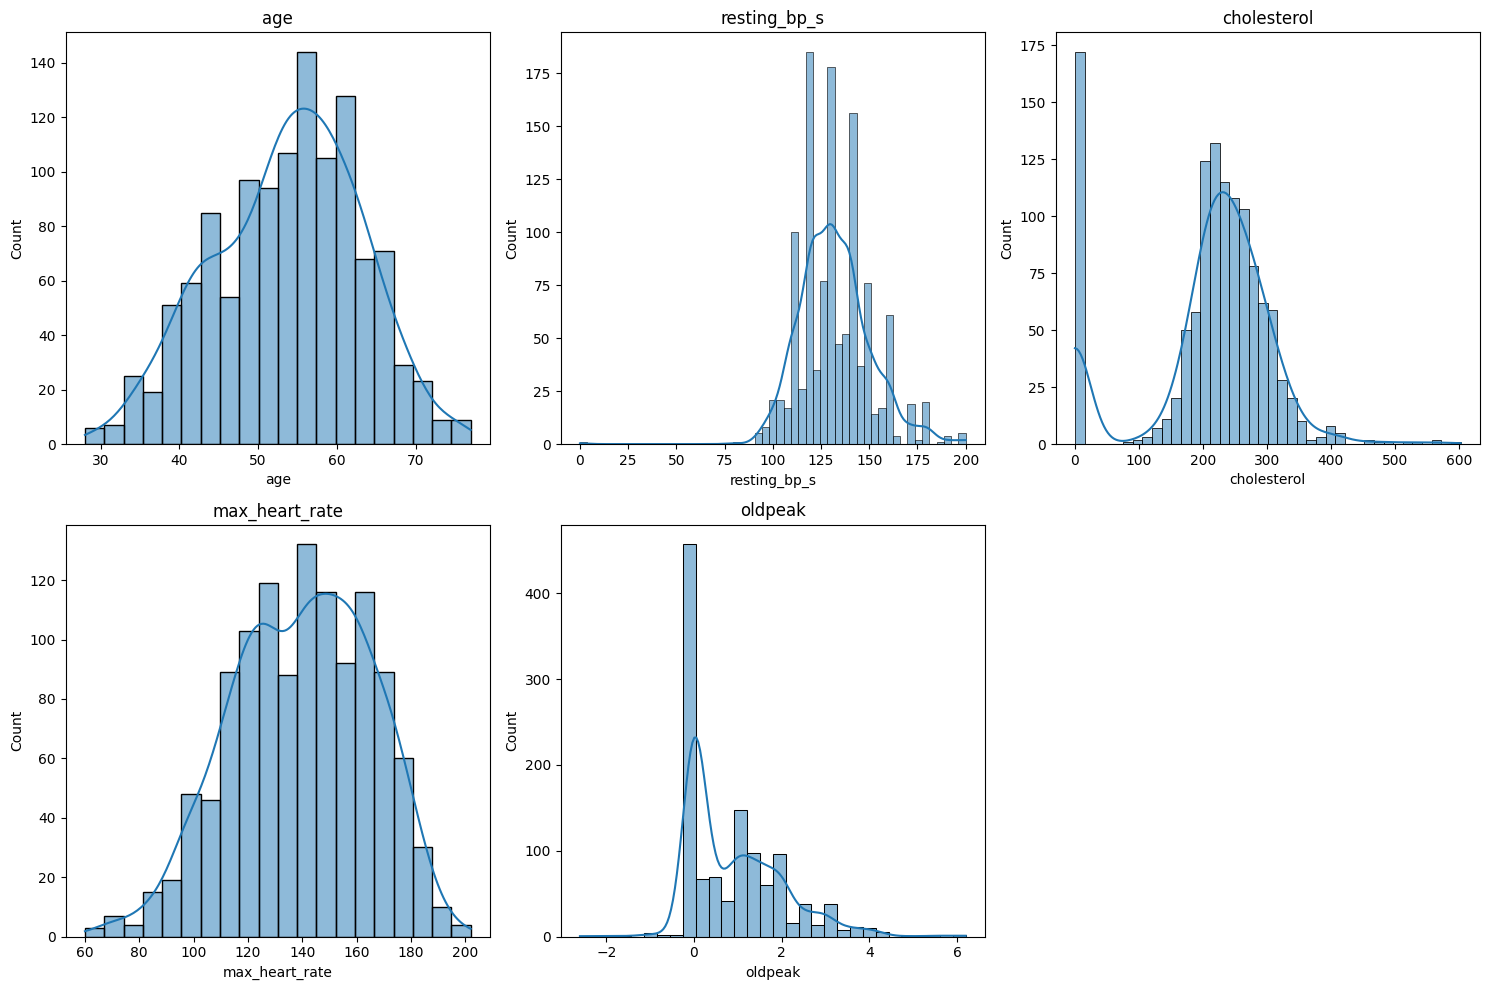

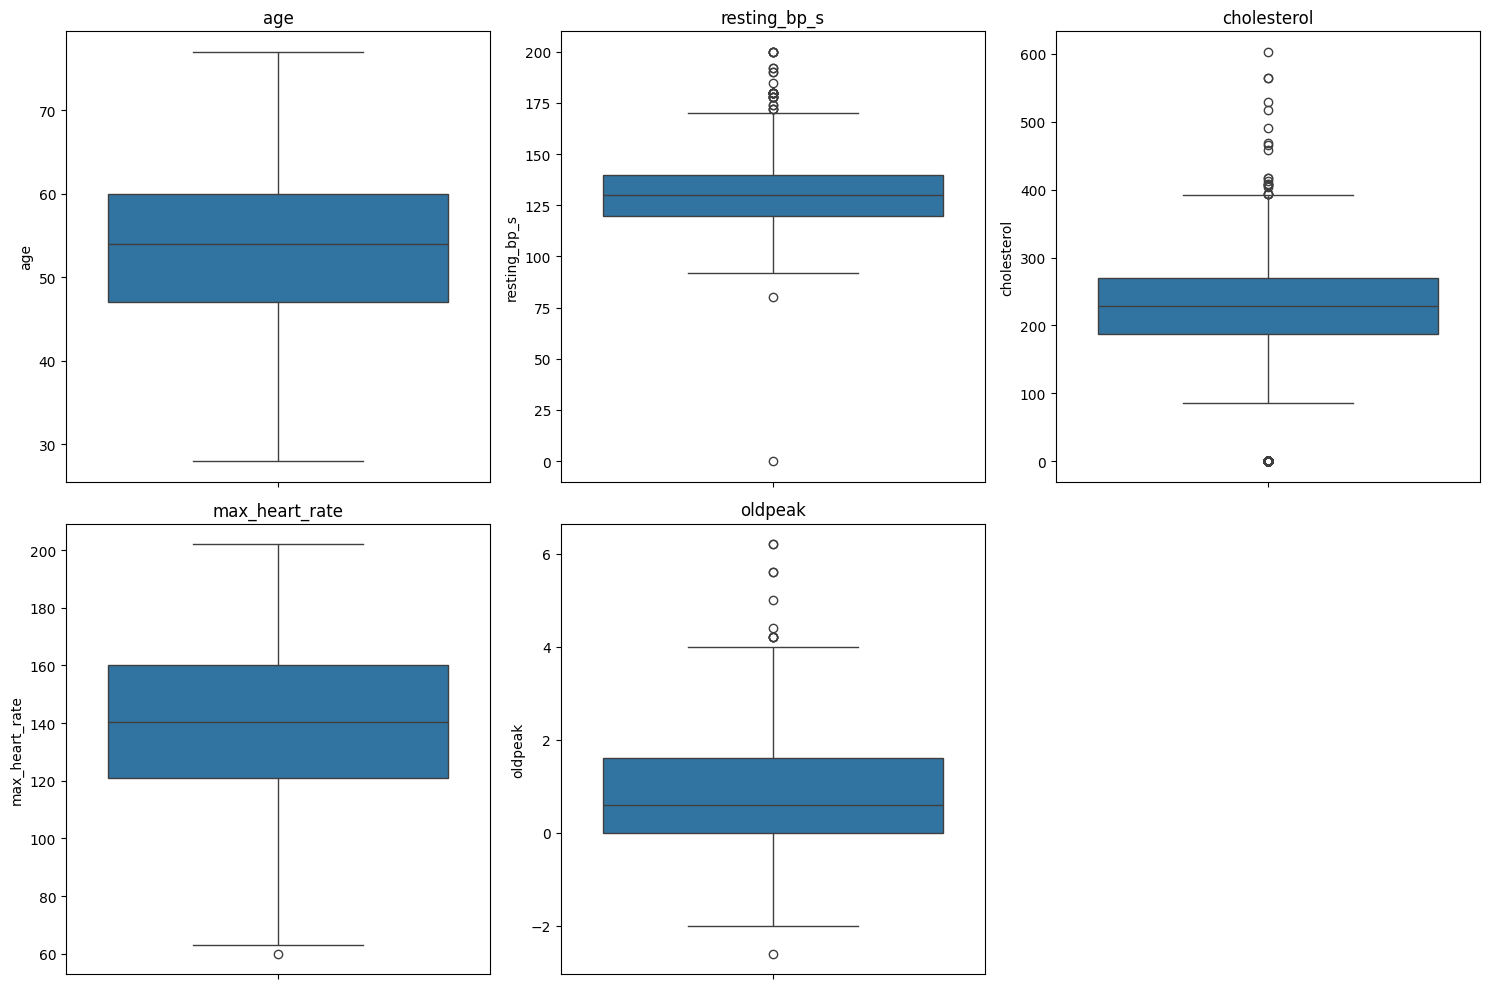

In [29]:
# tracer les hisplots pour les variables quantitatives
print("histogramme des variables quantitatives")
num_var = ['age', 'resting_bp_s', 'cholesterol', 'max_heart_rate', 'oldpeak']
# tracer le boxplot
plt.figure(figsize=(15, 10))
for i, var_name in enumerate(num_var):
  plt.subplot(2,3,i+1)
  sns.histplot(data[var_name], kde=True)
  plt.title(var_name)
plt.tight_layout()


# tracer les boxplots


plt.figure(figsize=(15, 10))
for i, var_name in enumerate(num_var):
  plt.subplot(2,3,i+1)
  sns.boxplot(data[var_name])
  plt.title(var_name)
plt.tight_layout()
print("boxplot des variables quantitatives")

l'hypothése de normalité n'est pas respecté. Donc ce qui veut dire que ce sont les tests non paramétriques que nous allons éffectuer pour notre dataset.

## Bivariate analysis

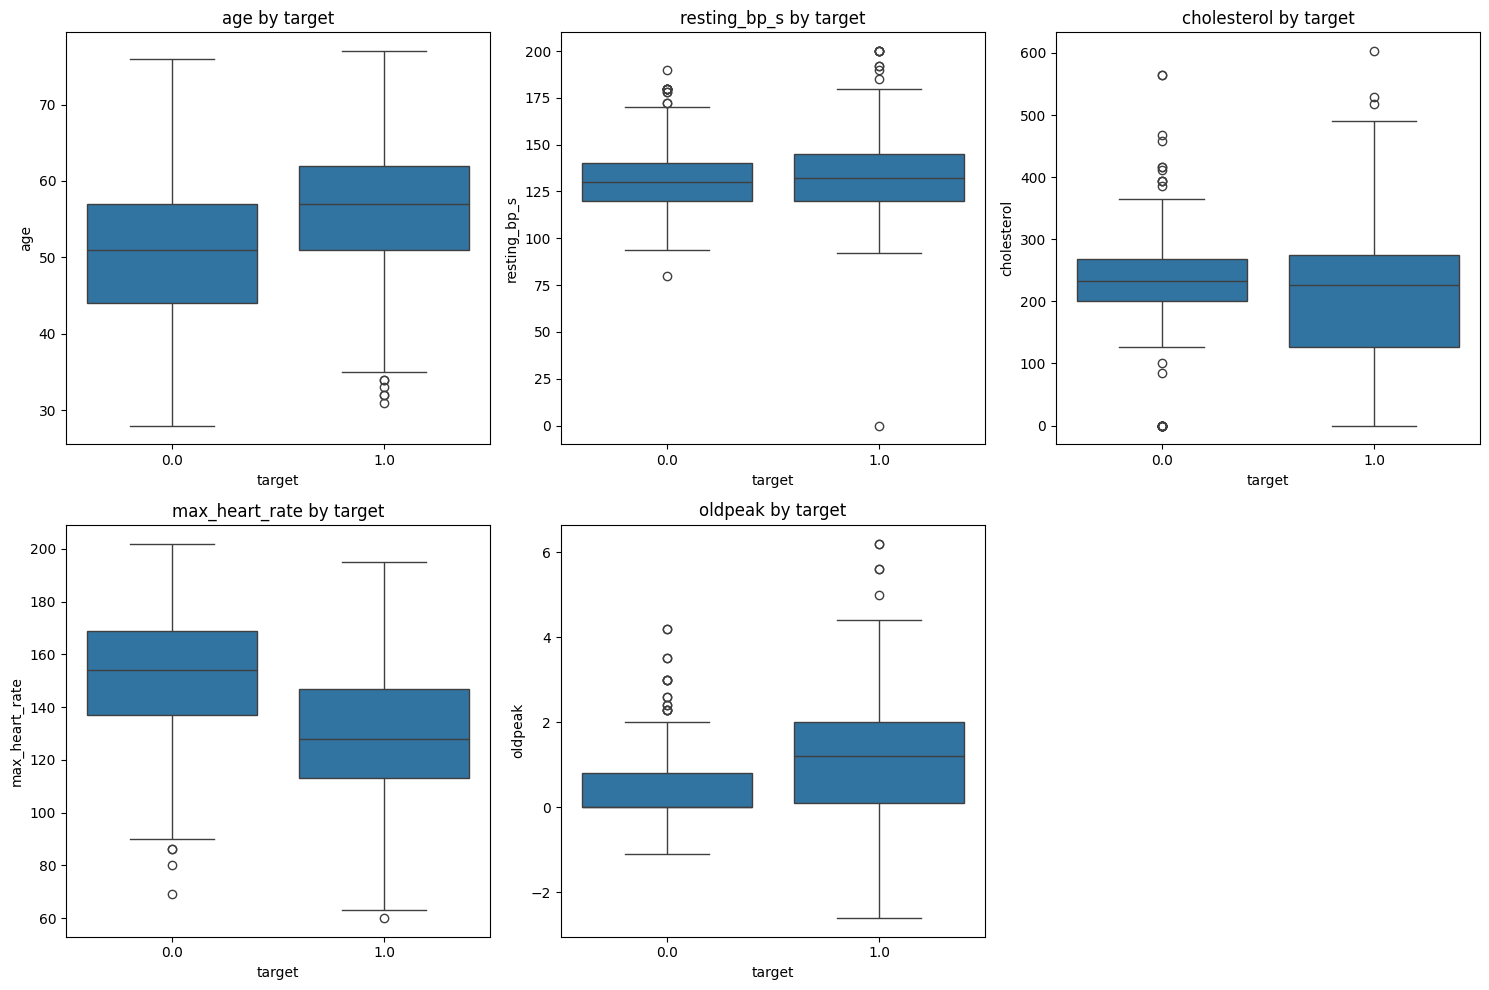

In [31]:
# tracer les boxplots entre la variables target et les autres variables
plt.figure(figsize=(15, 10))
for i, var_name in enumerate(num_var):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x=data['target'], y=data[var_name])
    plt.title(f'{var_name} by target')
plt.tight_layout()
plt.show()

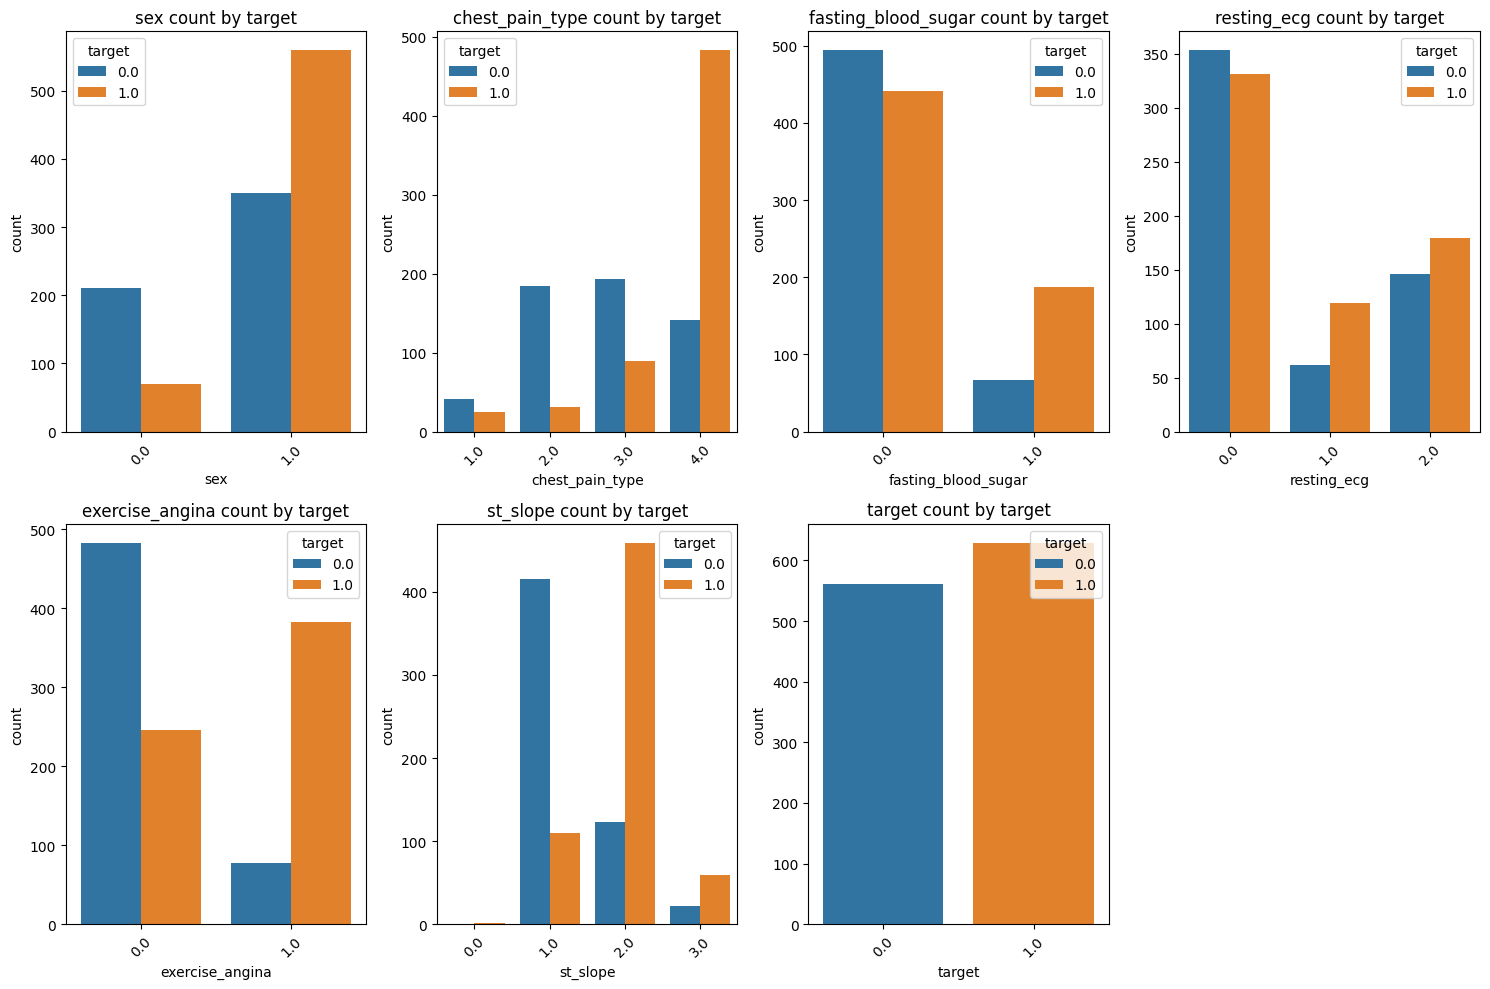

In [33]:
# tracer le boxplot entre la terget et la variable qualitative
plt.figure(figsize=(15, 10))
for i, var_name in enumerate(cat_var):
    plt.subplot(2, 4, i+1)
    sns.countplot(x=data[var_name], hue=data['target'])
    plt.title(f'{var_name} count by target')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## statistical testing

For quantitative data we make a correlation matrix

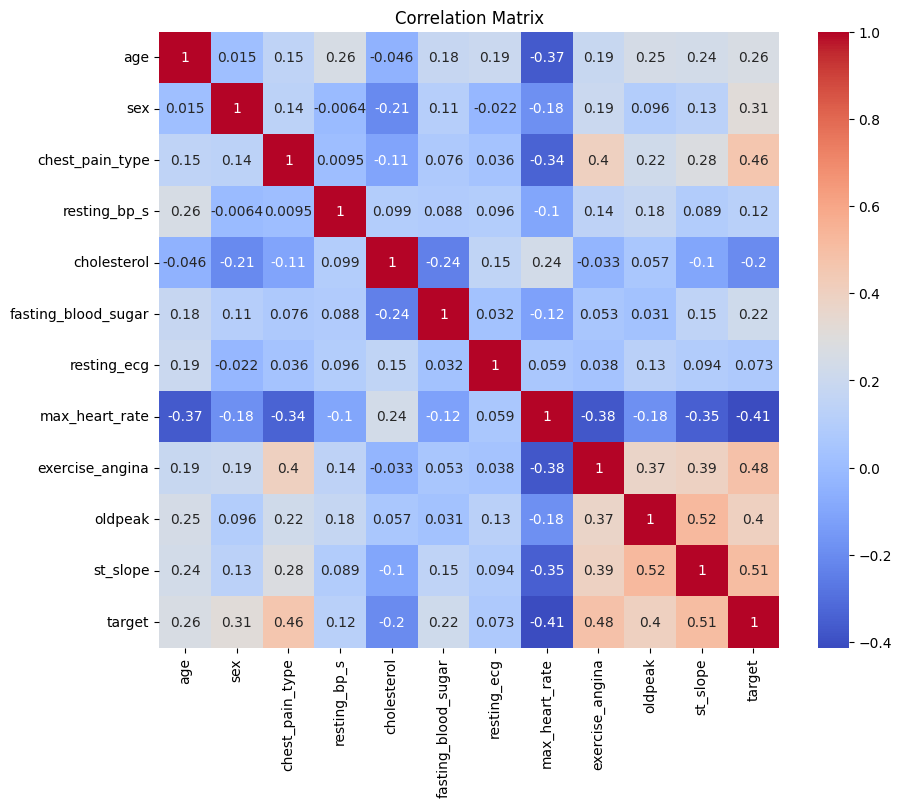

In [34]:
# tracer la matrice de correlation
corr_matrix = data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

#### t test or Mann withney - u test

le test t de student a pour Objectif de comparer la moyenne d’une variable quantitative entre 2 groupes indépendants.  
Hypothèses :

Variable quantitative distribuée (approx) normalement dans chaque groupe.

Variances homogènes (ou utiliser version avec variances inégales).

les courbes de densités que nous avons tracé précédemment nous a montré que nos variables n'étaient pas normalement distribuées.

In [36]:
# Do a shapiro wilk test to do normality
from scipy.stats import shapiro
# faire le test de shapiro wilk sur tous les variables quantitatives
for var in num_var:
  stat, p = shapiro(data[var])
  print('stat=%.3f, p=%.3f' % (stat, p))

  if p > 0.05:
    print(f"{var} is normally distributed")
  else:
    print(f"{var} is not normally distributed")


stat=0.991, p=0.000
age is not normally distributed
stat=0.961, p=0.000
resting_bp_s is not normally distributed
stat=0.866, p=0.000
cholesterol is not normally distributed
stat=0.990, p=0.000
max_heart_rate is not normally distributed
stat=0.859, p=0.000
oldpeak is not normally distributed


Comme le test de normalité n'est pas vérifié, donc ce qu'il faut faire c'est le test U de Mann Withney

In [38]:
# Do a Man withney u test
from scipy.stats import mannwhitneyu
# extraire les deux groupes à comparer
groupe1 = data[data['target'] == 0]['age']
groupe2 = data[data['target'] == 1]['age']
# faire le test de Mann Withney U
stat, p = mannwhitneyu(groupe1, groupe2, alternative='two-sided')

print(f"Statistique U = {stat}")
print(f"p-value = {p}")

if p < 0.05:
    print("Rejet de l'hypothèse nulle : les distributions sont différentes")
else:
    print("Pas de différence significative entre les deux groupes")



Statistique U = 121013.5
p-value = 7.254038634136111e-21
Rejet de l'hypothèse nulle : les distributions sont différentes


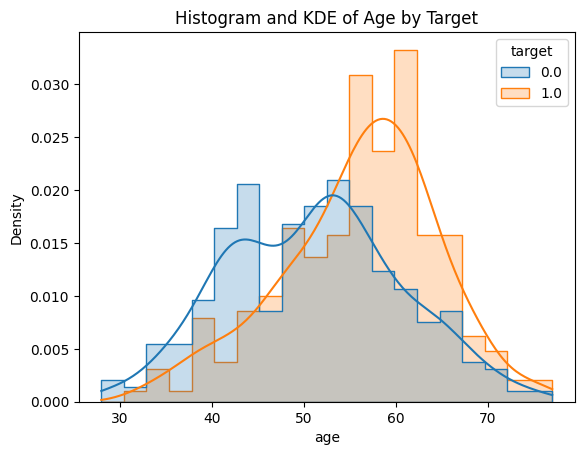

In [39]:
sns.histplot(data=data, x='age', hue='target', kde=True, element='step', stat='density')
plt.title("Histogram and KDE of Age by Target")
plt.show()

In [41]:
# Do a Man withney u test for each quantitative variable
from scipy.stats import mannwhitneyu

for var in num_var:
    # extraire les deux groupes à comparer pour la variable actuelle
    groupe1 = data[data['target'] == 0][var]
    groupe2 = data[data['target'] == 1][var]

    # faire le test de Mann Withney U
    stat, p = mannwhitneyu(groupe1, groupe2, alternative='two-sided')

    print(f"Variable: {var}")
    print(f"Statistique U = {stat}")
    print(f"p-value = {p}")

    if p < 0.05:
        print(f"Rejet de l'hypothèse nulle pour {var} : les distributions sont différentes")
    else:
        print(f"Pas de différence significative pour {var} entre les deux groupes")
    print("\n")

Variable: age
Statistique U = 121013.5
p-value = 7.254038634136111e-21
Rejet de l'hypothèse nulle pour age : les distributions sont différentes


Variable: resting_bp_s
Statistique U = 151645.5
p-value = 2.6301977222353945e-05
Rejet de l'hypothèse nulle pour resting_bp_s : les distributions sont différentes


Variable: cholesterol
Statistique U = 194093.5
p-value = 0.0028039369196026197
Rejet de l'hypothèse nulle pour cholesterol : les distributions sont différentes


Variable: max_heart_rate
Statistique U = 261978.0
p-value = 2.255696104723896e-47
Rejet de l'hypothèse nulle pour max_heart_rate : les distributions sont différentes


Variable: oldpeak
Statistique U = 95743.5
p-value = 8.67546496479804e-45
Rejet de l'hypothèse nulle pour oldpeak : les distributions sont différentes




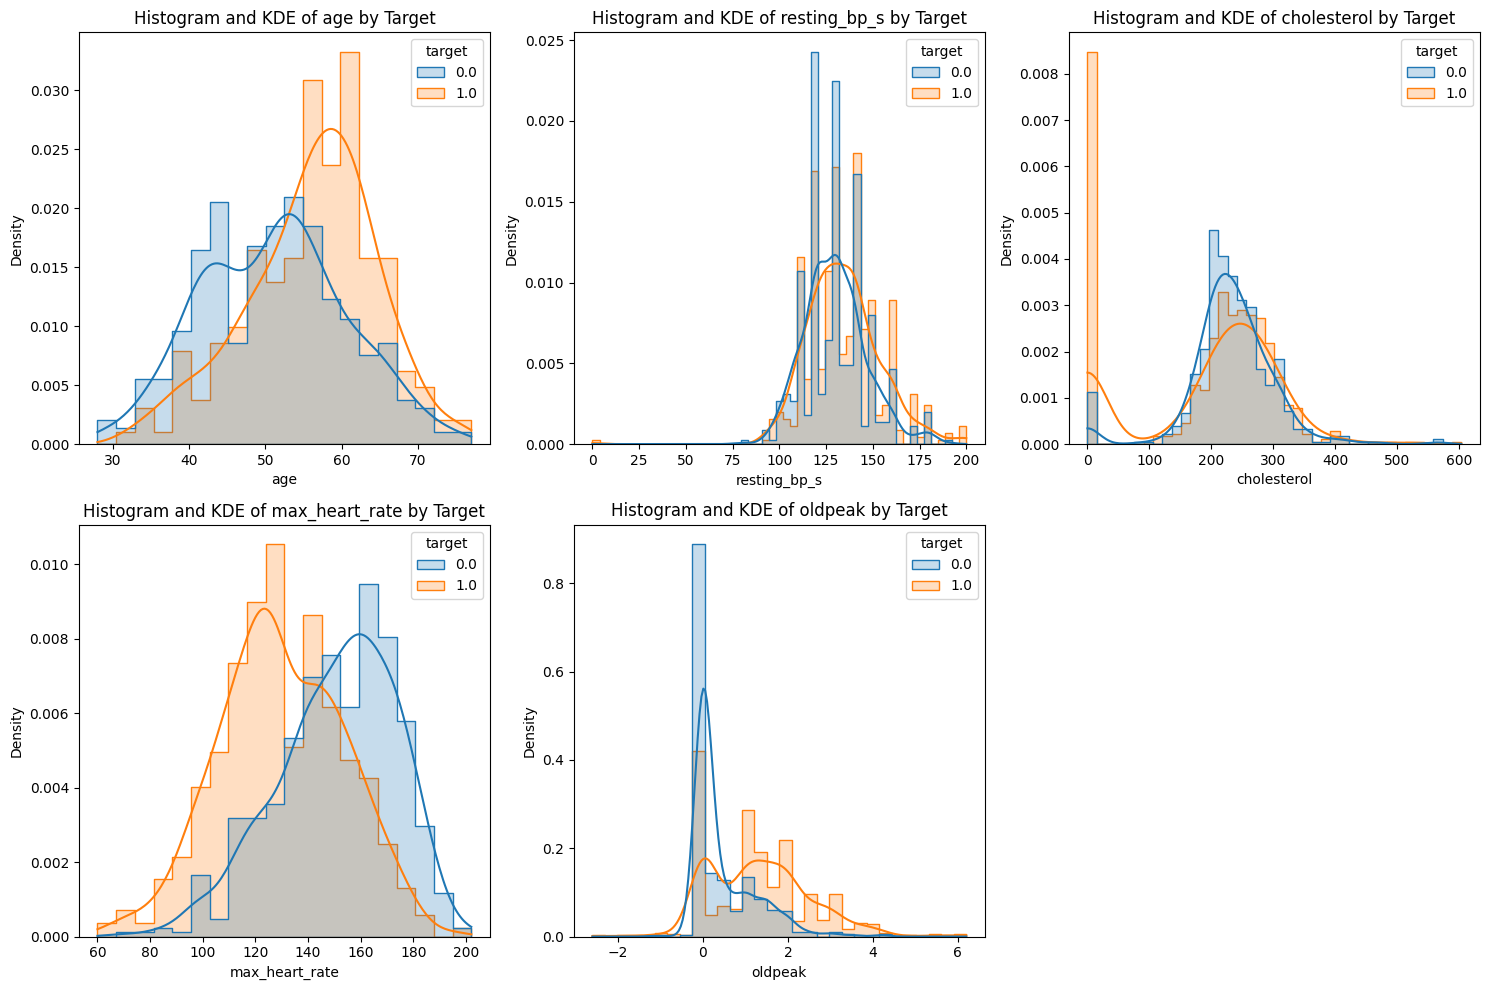

In [43]:
# To plot histograms for each quantitative variable, we need to loop through them
plt.figure(figsize=(15, 10))
for i, var_name in enumerate(num_var):
    plt.subplot(2, 3, i + 1) # Adjust subplot grid if needed, e.g., 2 rows, 3 columns
    sns.histplot(data=data, x=var_name, hue='target', kde=True, element='step', stat='density')
    plt.title(f"Histogram and KDE of {var_name} by Target")
plt.tight_layout()
plt.show()

### test Anova/kruskall wallis test

In [44]:
from scipy.stats import kruskal

In [51]:
# faire le test de kruskall wallis
def select_var(data, cat_vars, min_modalities=3):
    selected_vars = []
    for var in cat_vars:
        n_modalities = data[var].nunique(dropna=True)
        if n_modalities >= min_modalities:
            selected_vars.append(var)
    return selected_vars

# 'cat_var' was defined in a previous cell, ensuring it's available here.
vars_3modal = select_var(data, cat_var, min_modalities=3)
print("Variables avec au moins 3 modalités :", vars_3modal)

for cat_variable in vars_3modal:
    for num_variable in num_var: # Loop through each quantitative variable
        groups = [data[data[cat_variable] == modality][num_variable].dropna() for modality in data[cat_variable].dropna().unique()]
        # Ensure there are at least two groups to compare for Kruskal-Wallis
        # Also ensure that each group is not empty after dropping NaNs
        valid_groups = [g for g in groups if not g.empty]

        if len(valid_groups) > 1:
            stat, p = kruskal(*valid_groups)
            print(f"Kruskal-Wallis test for {cat_variable} vs {num_variable}: Statistique de kruskall={stat:.3f}, p_value={p:.3f}")
            print(f"")
        else:
            print(f"Not enough valid groups for Kruskal-Wallis test for {cat_variable} vs {num_variable}")




Variables avec au moins 3 modalités : ['chest_pain_type', 'resting_ecg', 'st_slope']
Kruskal-Wallis test for chest_pain_type vs age: Statistique de kruskall=58.631, p_value=0.000

Kruskal-Wallis test for chest_pain_type vs resting_bp_s: Statistique de kruskall=14.361, p_value=0.002

Kruskal-Wallis test for chest_pain_type vs cholesterol: Statistique de kruskall=9.397, p_value=0.024

Kruskal-Wallis test for chest_pain_type vs max_heart_rate: Statistique de kruskall=162.883, p_value=0.000

Kruskal-Wallis test for chest_pain_type vs oldpeak: Statistique de kruskall=140.557, p_value=0.000

Kruskal-Wallis test for resting_ecg vs age: Statistique de kruskall=57.236, p_value=0.000

Kruskal-Wallis test for resting_ecg vs resting_bp_s: Statistique de kruskall=16.747, p_value=0.000

Kruskal-Wallis test for resting_ecg vs cholesterol: Statistique de kruskall=61.538, p_value=0.000

Kruskal-Wallis test for resting_ecg vs max_heart_rate: Statistique de kruskall=53.084, p_value=0.000

Kruskal-Wallis 